In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

flights = pd.read_csv('flights.csv', nrows=100000, low_memory=False)
print("Shape:", flights.shape)
display(flights.head())
flights.info()

Shape: (100000, 31)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 100000 non-null  int64  
 1   MONTH                100000 non-null  int64  
 2   DAY                  100000 non-null  int64  
 3   DAY_OF_WEEK          100000 non-null  int64  
 4   AIRLINE              100000 non-null  object 
 5   FLIGHT_NUMBER        100000 non-null  int64  
 6   TAIL_NUMBER          99833 non-null   object 
 7   ORIGIN_AIRPORT       100000 non-null  object 
 8   DESTINATION_AIRPORT  100000 non-null  object 
 9   SCHEDULED_DEPARTURE  100000 non-null  int64  
 10  DEPARTURE_TIME       97702 non-null   float64
 11  DEPARTURE_DELAY      97702 non-null   float64
 12  TAXI_OUT             97629 non-null   float64
 13  WHEELS_OFF           97629 non-null   float64
 14  SCHEDULED_TIME       100000 non-null  int64  
 15  ELAPSED_TIME      

In [3]:
# ============================================================
# CO1 - Data Cleaning
# ============================================================

print("Missing values:\n", flights.isnull().sum())
print("Duplicates:", flights.duplicated().sum())

# Drop duplicates
flights = flights.drop_duplicates()

# Fill missing delay values with 0 (no delay recorded = no delay)
delay_cols = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'AIR_SYSTEM_DELAY',
              'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
              'WEATHER_DELAY']

for col in delay_cols:
    if col in flights.columns:
        flights[col] = flights[col].fillna(0)

# Drop rows where key columns are missing
flights = flights.dropna(subset=['DEPARTURE_DELAY', 'ARRIVAL_DELAY'])

print("\nAfter Cleaning - Shape:", flights.shape)
print("Missing values after cleaning:\n", flights[delay_cols].isnull().sum())

Missing values:
 YEAR                       0
MONTH                      0
DAY                        0
DAY_OF_WEEK                0
AIRLINE                    0
FLIGHT_NUMBER              0
TAIL_NUMBER              167
ORIGIN_AIRPORT             0
DESTINATION_AIRPORT        0
SCHEDULED_DEPARTURE        0
DEPARTURE_TIME          2298
DEPARTURE_DELAY         2298
TAXI_OUT                2371
WHEELS_OFF              2371
SCHEDULED_TIME             0
ELAPSED_TIME            2613
AIR_TIME                2613
DISTANCE                   0
WHEELS_ON               2440
TAXI_IN                 2440
SCHEDULED_ARRIVAL          0
ARRIVAL_TIME            2440
ARRIVAL_DELAY           2613
DIVERTED                   0
CANCELLED                  0
CANCELLATION_REASON    97611
AIR_SYSTEM_DELAY       65375
SECURITY_DELAY         65375
AIRLINE_DELAY          65375
LATE_AIRCRAFT_DELAY    65375
WEATHER_DELAY          65375
dtype: int64
Duplicates: 0

After Cleaning - Shape: (100000, 31)
Missing values afte

In [4]:
# ============================================================
# CO2 - Descriptive Statistics
# ============================================================

num_cols = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'AIR_TIME', 'DISTANCE']
num = flights[num_cols]

display(num.describe())
print("Median:\n", num.median())
print("Mode:\n", num.mode().iloc[0])
print("Variance:\n", num.var())
print("Standard Deviation:\n", num.std())
print("IQR:\n", num.quantile(0.75) - num.quantile(0.25))

,DEPARTURE_DELAY,ARRIVAL_DELAY,AIR_TIME,DISTANCE
count,100000.000000,100000.000000,97387.000000,100000.000000
mean,19.479580,17.863020,117.098032,830.389430
std,45.412142,48.324073,74.306645,609.183228
min,-39.000000,-65.000000,8.000000,31.000000
25%,-3.000000,-8.000000,62.000000,377.000000
50%,2.000000,3.000000,98.000000,669.000000
75%,24.000000,26.000000,150.000000,1069.000000
max,1380.000000,1384.000000,676.000000,4983.000000


Median:
 DEPARTURE_DELAY      2.0
ARRIVAL_DELAY        3.0
AIR_TIME            98.0
DISTANCE           669.0
dtype: float64
Mode:
 DEPARTURE_DELAY      0.0
ARRIVAL_DELAY        0.0
AIR_TIME            62.0
DISTANCE           337.0
Name: 0, dtype: float64
Variance:
 DEPARTURE_DELAY      2062.262606
ARRIVAL_DELAY        2335.215989
AIR_TIME             5521.477554
DISTANCE           371104.205336
dtype: float64
Standard Deviation:
 DEPARTURE_DELAY     45.412142
ARRIVAL_DELAY       48.324073
AIR_TIME            74.306645
DISTANCE           609.183228
dtype: float64
IQR:
 DEPARTURE_DELAY     27.0
ARRIVAL_DELAY       34.0
AIR_TIME            88.0
DISTANCE           692.0
dtype: float64


Probability of departure delay > 15 min: 0.3184
Probability of cancellation: 0.0239


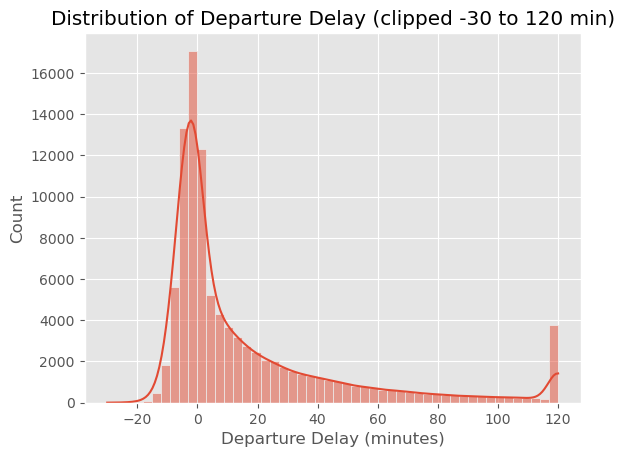

In [5]:
# ============================================================
# CO3 - Probability
# ============================================================

# P(flight is delayed by more than 15 minutes)
delayed = (flights['DEPARTURE_DELAY'] > 15).mean()
print(f"Probability of departure delay > 15 min: {delayed:.4f}")

# P(flight is cancelled)
if 'CANCELLED' in flights.columns:
    cancelled = flights['CANCELLED'].mean()
    print(f"Probability of cancellation: {cancelled:.4f}")

# Distribution of Departure Delay
sns.histplot(flights['DEPARTURE_DELAY'].clip(-30, 120), kde=True, bins=50)
plt.title('Distribution of Departure Delay (clipped -30 to 120 min)')
plt.xlabel('Departure Delay (minutes)')
plt.show()

In [6]:
# ============================================================
# CO4 - Hypothesis Testing
# ============================================================

# t-test: Is mean departure delay significantly different from 0?
t_stat, p_val = stats.ttest_1samp(
    flights['DEPARTURE_DELAY'].dropna(), 0
)
print(f"One-sample t-test (Departure Delay vs 0):")
print(f"  t-statistic = {t_stat:.4f}, p-value = {p_val:.4f}")
if p_val < 0.05:
    print("  Result: Mean delay is significantly different from 0 (reject H0)")
else:
    print("  Result: No significant difference from 0 (fail to reject H0)")

# Chi-square: Is delay related to airline?
flights['DELAYED'] = (flights['DEPARTURE_DELAY'] > 15).astype(int)
contingency = pd.crosstab(flights['AIRLINE'], flights['DELAYED'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square test (Airline vs Delay):")
print(f"  chi2 = {chi2:.4f}, p-value = {p:.4f}, dof = {dof}")
if p < 0.05:
    print("  Result: Delay is significantly associated with airline (reject H0)")
else:
    print("  Result: No significant association (fail to reject H0)")

One-sample t-test (Departure Delay vs 0):
  t-statistic = 135.6462, p-value = 0.0000
  Result: Mean delay is significantly different from 0 (reject H0)

Chi-square test (Airline vs Delay):
  chi2 = 3195.4553, p-value = 0.0000, dof = 13
  Result: Delay is significantly associated with airline (reject H0)


,DEPARTURE_DELAY,ARRIVAL_DELAY,AIR_TIME,DISTANCE
DEPARTURE_DELAY,1.000000,0.946109,0.002733,0.009544
ARRIVAL_DELAY,0.946109,1.000000,-0.002742,-0.019342
AIR_TIME,0.002733,-0.002742,1.000000,0.976169
DISTANCE,0.009544,-0.019342,0.976169,1.000000


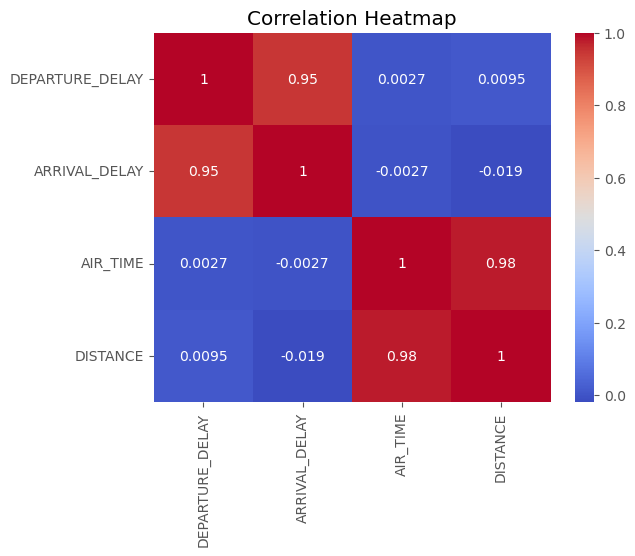

Linear Regression: Departure Delay → Arrival Delay
  MSE  : 244.9097
  RMSE : 15.6496
  MAE  : 10.5056
  R²   : 0.8951


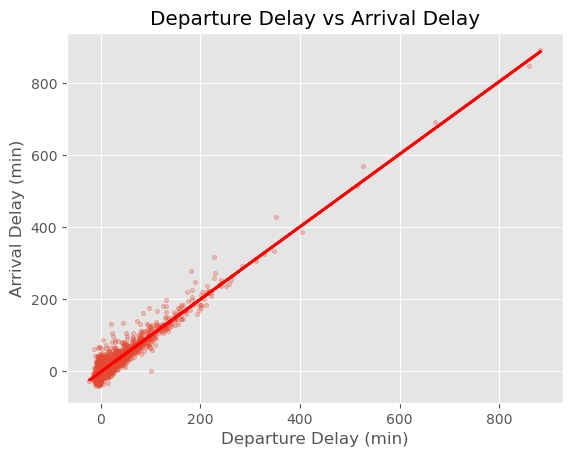

In [7]:
# ============================================================
# CO5 - Correlation & Regression
# ============================================================

# Correlation
corr_cols = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'AIR_TIME', 'DISTANCE']
corr = flights[corr_cols].corr()
display(corr)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Linear Regression: Predict Arrival Delay from Departure Delay
df_reg = flights[['DEPARTURE_DELAY', 'ARRIVAL_DELAY']].dropna()
X = df_reg[['DEPARTURE_DELAY']]
y = df_reg['ARRIVAL_DELAY']

model = LinearRegression().fit(X, y)
pred = model.predict(X)

print("Linear Regression: Departure Delay → Arrival Delay")
print(f"  MSE  : {mean_squared_error(y, pred):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y, pred)):.4f}")
print(f"  MAE  : {mean_absolute_error(y, pred):.4f}")
print(f"  R²   : {r2_score(y, pred):.4f}")

# Scatter + Regression Line (sample for speed)
sample = df_reg.sample(3000, random_state=42)
plt.scatter(sample['DEPARTURE_DELAY'], sample['ARRIVAL_DELAY'],
            alpha=0.3, s=10)
plt.plot(sample['DEPARTURE_DELAY'],
         model.predict(sample[['DEPARTURE_DELAY']]),
         color='red', linewidth=2)
plt.xlabel('Departure Delay (min)')
plt.ylabel('Arrival Delay (min)')
plt.title('Departure Delay vs Arrival Delay')
plt.show()

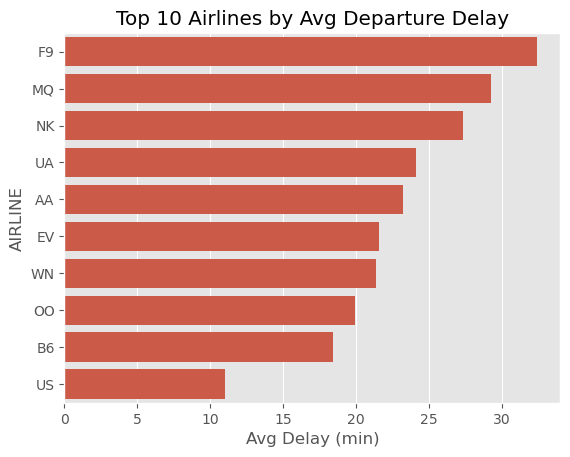

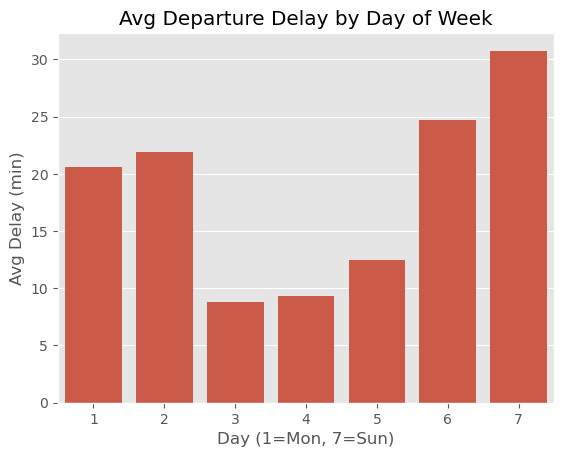

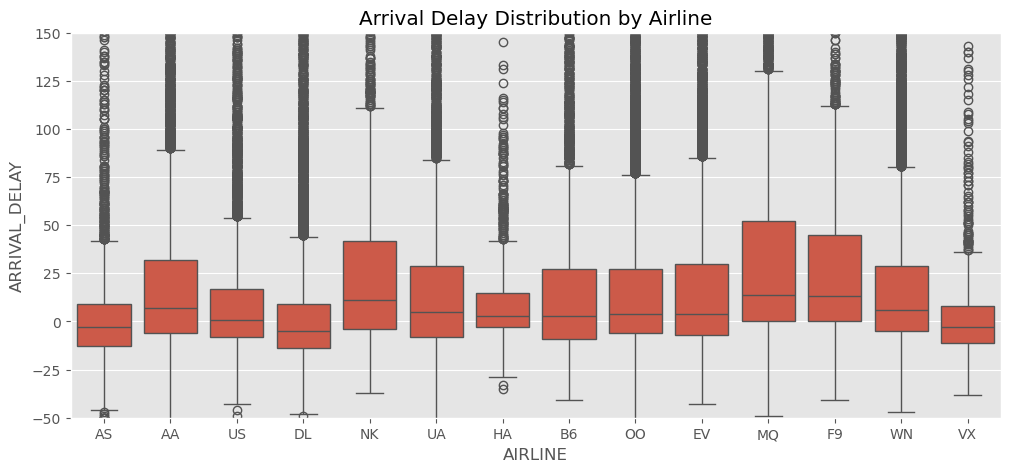

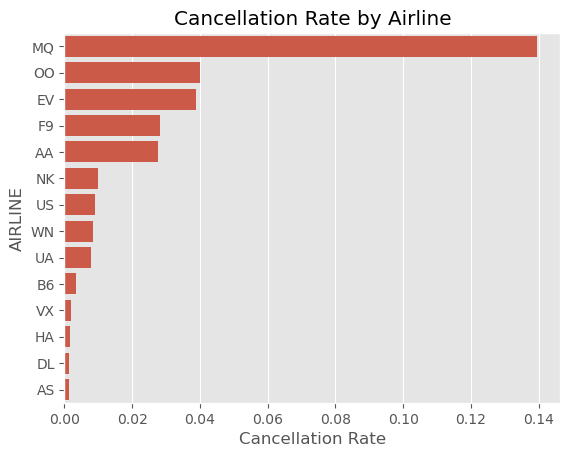

In [8]:
# ============================================================
# CO6 - Visualization & Insights
# ============================================================

# 1. Top 10 Airlines by Average Departure Delay
avg_delay = flights.groupby('AIRLINE')['DEPARTURE_DELAY'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=avg_delay.values, y=avg_delay.index)
plt.title('Top 10 Airlines by Avg Departure Delay')
plt.xlabel('Avg Delay (min)')
plt.show()

# 2. Delay by Day of Week
if 'DAY_OF_WEEK' in flights.columns:
    day_delay = flights.groupby('DAY_OF_WEEK')['DEPARTURE_DELAY'].mean()
    sns.barplot(x=day_delay.index, y=day_delay.values)
    plt.title('Avg Departure Delay by Day of Week')
    plt.xlabel('Day (1=Mon, 7=Sun)')
    plt.ylabel('Avg Delay (min)')
    plt.show()

# 3. Boxplot of Arrival Delay by Airline
plt.figure(figsize=(12, 5))
sns.boxplot(data=flights, x='AIRLINE', y='ARRIVAL_DELAY')
plt.ylim(-50, 150)
plt.title('Arrival Delay Distribution by Airline')
plt.show()

# 4. Cancellation rate by airline
if 'CANCELLED' in flights.columns:
    cancel_rate = flights.groupby('AIRLINE')['CANCELLED'].mean().sort_values(ascending=False)
    sns.barplot(x=cancel_rate.values, y=cancel_rate.index)
    plt.title('Cancellation Rate by Airline')
    plt.xlabel('Cancellation Rate')
    plt.show()